# Day 22 Pre-Class Assignment
---


### <p style="text-align: right;"> &#9989;&nbsp; Put your name here</p>

## A Statistical Recap

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/phd_control_variables.gif" style="display:block; margin-left: auto; margin-right: auto; width: 65%" alt="Comic about the unrealistic expectations in research to just keep collecting more and more data WHILE also understanding it.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://phdcomics.com/comics/archive.php?comicid=1453" target="_blank">PHDcomics.com</a></p>

### Learning goals for today's pre-class assignment

* Review the statistical concepts we have covered in the past days:
   * Hypothesis testing
   * Central Limit Theorem
   * Confidence intervals and how they relate to the CLT


## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

In [1]:
# Loading libraries before anything else
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

We will make jitterplots across the assignment (and other plots), so it is good idea to define some variables from the the get-go

In [2]:
# Random noise for the jitterplots
rng = np.random.default_rng(seed = 42)
nudge = rng.uniform(-0.15, 0.15, 1000)

# Lists of colors and markers
colors = ["#a1dab4", "#41b6c4", "#2c7fb8", "#253494", "#ffffcc"]
markers = ['o', '^', 's', 'D', 'v']

# fontsize for all the plots
fs = 12

----

## 1. Hypothesis testing and the null hypothesis: Christmas tubeworms

<img src="https://upload.wikimedia.org/wikipedia/commons/e/ef/Spirobranchus_giganteus_%28Red_and_white_christmas_tree_worm%29.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 40%" alt="Spirobranchus giganteus (Red and white Christmas tree worm).">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://en.wikipedia.org/wiki/Serpulidae" target="_blank">Wikipedia.org</a></p>

Back a few days, we saw the Christmas tubeworm dataset from [S&aacute;nchez-Ovando et al (2025)](https://doi.org/10.1002/jez.70008). These cute critters are ocean's natural filters, as they eat and collect all sorts of random organic bits floating in the water. As [ZeFrank](https://www.youtube.com/watch?v=5DH9IZ01Qqg) put it:

> Imagine a bunch of Williamsburg hipsters that fell into a ballpit up to their mustaches, and have to use them to capture kale chip crumbs and quinoa. That is how the Christmas treeworm do.
>
> (*Warning if you watch the rest of the linked video: ZeFrank can be quite irreverent*)

Temperature is one of the main abiotic factors influencing the worms physiology and metabolic responses, as well as their growth, survival, and distribution patterns. Physiologists are interested in understanding how the current ocean warming could affect them due to increased CO<sub>2</sub> emissions, and how they could respond to these environmental changes in the near future.

### 1.1 Loading, wrangling, and plotting the data

Let's look at the data for ammonia excretion rates for two tubeworm species across different water temperatures.

In [3]:
# Load oxygen data for both species
species = ['S spinosus', 'S cf corniculatus']
measurement = 'Ammonia excretion'

# Empty dictionary to store the data
data = dict()

for specie in species:
    # Excels with multiple sheets are loaded as dictionaries
    # The dictionary keys correspond to the sheet names
    excel = pd.read_excel(specie + '.xlsx', sheet_name=None)
    data[specie] = excel[measurement]

data[specie]

,24°C,27°C,30°C,33°C
0,0.175000,0.188000,0.177421,0.266000
1,0.158000,0.185055,0.285187,0.224817
2,0.256000,0.130000,0.204285,0.249000
3,0.166568,0.180311,0.222242,0.245272
4,0.142370,0.138020,0.216500,0.244449
5,0.144967,0.158744,0.234917,0.234147


Now we plot all the data. You might have done something like this for In-Class 18, albeit for a single species.

**Note**: The dashed bars indicate **standard deviation** instead of standard error.

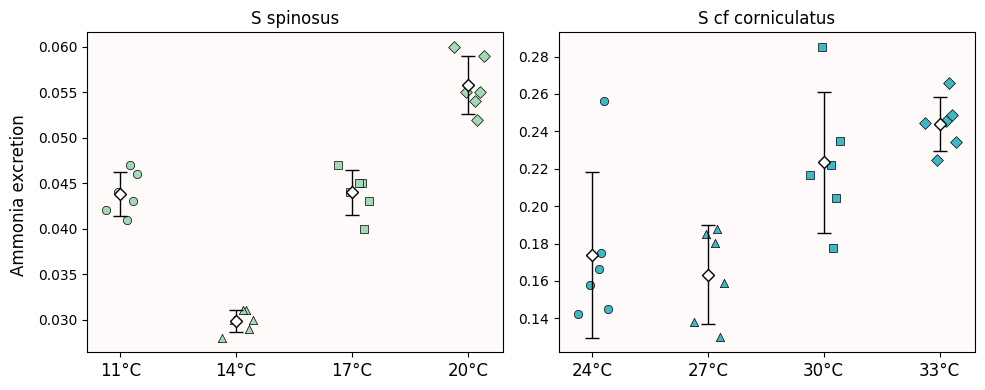

In [4]:
# Arrange subplots in a single row and 2 columns (because we have 2 tubeworm species)
fig, ax = plt.subplots(1, len(species), figsize=(5*len(species), 4), sharex=False, sharey=False)

for i in range(len(species)):
    # Focus on one tubeworm species data at a time
    df = data[species[i]]

    # Set titles and x-axis
    ax[i].set_facecolor('snow')
    ax[i].set_title(species[i], fontsize=fs)
    ax[i].set_xticks(range(df.shape[1]), df.columns, fontsize=fs);

    # Loop through each column (temperature)
    for j in range(df.shape[1]):
        # Do a jitterplot with 95% confidence intervals
        yvals = df.iloc[:,j]
        ci = stats.t.ppf(0.975, len(yvals)-1)*yvals.sem()

        ax[i].scatter( j + nudge[:len(yvals)], yvals, c=colors[i], marker=markers[j], ec='k', lw=0.5, zorder=1)
        ax[i].errorbar(j , yvals.mean(), yerr=ci, color='k', mew=1, elinewidth=1, capsize=5, mfc='w', marker='D', zorder=3)

fig.supylabel(measurement, fontsize=fs)
plt.tight_layout();

### 1.2 Is the data normalish?

Before statistically checking for differences, we must determine whether the excretion values follow a normal distribution or not. We do a visual assessment with Q-Q plots.

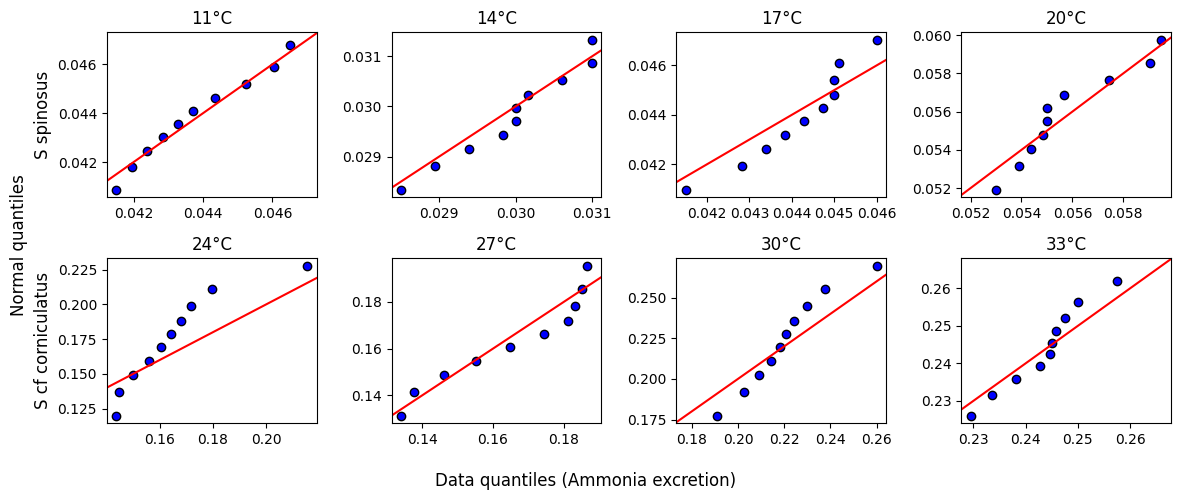

In [5]:
# All eight Q-Q plots at once
quantiles = np.linspace(0.1, 0.9, 10)

fig, ax = plt.subplots(2, 4, figsize=(12, 5))
for i in range(ax.shape[0]):
    ax[i,0].set_ylabel(species[i], fontsize=fs)
    for j in range(ax.shape[1]):

        # Ammonia excretion for a single species at a single temperature
        y = data[species[i]].iloc[:,j]

        dataq = np.quantile(y, quantiles)
        normq = stats.norm.ppf(quantiles, loc=y.mean(), scale=y.std())

        ax[i,j].scatter(dataq, normq, c='b', ec='k')
        ax[i,j].axline([y.iloc[0], y.iloc[0]], slope=1, c='r')
        ax[i,j].set_title(y.name, fontsize=fs)

fig.supxlabel('Data quantiles (' + measurement +')', fontsize=fs)
fig.supylabel('Normal quantiles', fontsize=fs)
fig.tight_layout()

- Most of the data for *S. spinosus* follows the identity line and looks normal-ish enough.
- Results are mixed with *S. cf corniculatus*.

**However**, what really matters for a Q-Q plot is if the quantiles follow a linear relationship. Usually it is the identity line, but it is not necessary. For example, the data for 24&deg;C seems mostly aligned.

With *S. cf corniculatus* the normality claim can go either way.

### 1.2 t-tests with *S. spinosus*

We can then compute a Welch's t-test between ammonia excretion rates at 11&deg;C and 14&deg;C:

```python
df = data[species[0]]
stats.ttest_ind(df.iloc[:,0], df.iloc[:,1], equal_var=False)
```

&#9989;&nbsp; **Question 1**

In tubeworm terms, what is the null hypothesis being tested with the t-test above?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


However, we ultimately want to test *multiple* temperatures. So after running the t-tests, we must adjust their p-values with Benjamini-Hochberg.

In [6]:
df = data[species[0]]

pvalues = pd.Series()
for i in range( df.shape[1]-1):
    for j in range(i+1, df.shape[1]):
        ttest = stats.ttest_ind(df.iloc[:,i], df.iloc[:,j], equal_var = False)
        index = f'{df.columns[i]} vs {df.columns[j]}'
        pvalues.loc[index] = ttest.pvalue
pvalues = pd.Series(stats.false_discovery_control(pvalues), index=pvalues.index)
pvalues

11°C vs 14°C    0.000005
11°C vs 17°C    0.904330
11°C vs 20°C    0.000035
14°C vs 17°C    0.000005
14°C vs 20°C    0.000004
17°C vs 20°C    0.000035
dtype: float64

&#9989;&nbsp; **Question 2**

Let's say that any p-value lower than 0.05 will be considered significant.

When comparing 11&deg;C and 14&deg;C, we get an adjusted p-value of `0.00005`. Which of the following statement(s) is(are) correct?

- We reject the null hypothesis
- We cannot reject the null hypothesis
- The null hypothesis must be true
- The null hypothesis must be false

Explain your choice(s)

<font size=6 color="#009600">&#9998;</font> *Put your answers here.*


&#9989;&nbsp; **Question 3**

Now we want to compare excretion rates between 11&deg;C and 17&deg;C. What is the null hypothesis being tested in this case, in tubeworm terms?

<font size=6 color="#009600">&#9998;</font> *Put your answers here.*


&#9989;&nbsp; **Question 4**

We got adjusted p-value of `0.9` this time around. Similar to Q2, which of the following statement(s) is(are) correct now?

- We reject the null hypothesis
- We cannot reject the null hypothesis
- The null hypothesis must be true
- The null hypothesis must be false

Explain your choice(s)

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


### 1.3 t-tests with *S. cf cornicolatus*

Let's switch species. Just like above, we will do Welch's and adjust for false positives.

In [7]:
df = data[species[1]]

pvalues = pd.Series()
for i in range( df.shape[1]-1):
    for j in range(i+1, df.shape[1]):
        ttest = stats.ttest_ind(df.iloc[:,i], df.iloc[:,j], equal_var = False)
        index = f'{df.columns[i]} vs {df.columns[j]}'
        pvalues.loc[index] = ttest.pvalue
pvalues = pd.Series(stats.false_discovery_control(pvalues), index=pvalues.index)
pvalues

24°C vs 27°C    0.615121
24°C vs 30°C    0.080623
24°C vs 33°C    0.017124
27°C vs 30°C    0.017124
27°C vs 33°C    0.000842
30°C vs 33°C    0.284831
dtype: float64

&#9989;&nbsp; **Question 5**

When looking at the p-value corresponding to the excretion rates at 30&deg;C and 33&deg;C:

- What is the null hypothesis being tested in this case, in tubeworm terms?

<font size=6 color="#009600">&#9998;</font> *Put your answers here.*


&#9989;&nbsp; **Question 6**

Similar to Q2, which of the following statement(s) is(are) correct now?

- We reject the null hypothesis
- We cannot reject the null hypothesis
- The null hypothesis must be true
- The null hypothesis must be false

Explain your choice(s)

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Question 7**

We can have a long discussion on whether the data for *S. cf corniculatus* is truly normalish and if a Welch's t-test is a good choice. **However**, keep in mind the broader picture: the p-values should complement, not drive, your story.

- Visually speaking, does the visualization&mdash;jitterplots and confidence intervals&mdash;support your answers from Q5 and Q6?

<font size=6 color="#009600">&#9998;</font> *Put your answers here.*


---

## 4. Truly *high* confidence

Let's review one last time the &Delta;9-THC concentration data in hemp-fed cattle fat. If you recall,  [Fritz et al (2025)](https://doi.org/10.1038/s41598-025-26448-5) claim that:

> Concentration of 9-THC was the **upper 99% CI** from the day with the highest 9-THC concentrations in cattle adipose tissue (day 2): **74.7 ng/g**

&#9989;&nbsp;  **Question 8**

Recall that all the data was obtained from $n=4$ cows. Do you think the 99% confidence interval formula will indeed have a 99% chance of containing the true 9-THC mean concentration?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


### 4.1 Is hemp-fed cattle actually safe?

Let's load one last time the concentration data and summarize the mean, SE, and sample size $n$ for every tissue-day combination. This time, we set `as_index = True` so the times are the DataFrame indices.

In [8]:
# Load the data
safety = pd.read_csv('safety_limits.csv', index_col=0) # make the ages (first column) the indices names instead
tconc = pd.read_csv('concentration_raw.csv').fillna(0) # the original data has NaNs whenever no measurement was recorded

# Make a summary DataFrame of just the adipose tissue
# We can use groupby to do it in a single line
tissue = 'Adipose'
cannabinoid = '9-THC'
concentrations = tconc[tconc['Tissue'] == tissue].groupby(['Time (d)'], as_index=True)[cannabinoid].agg(['mean', 'sem', 'count'])
concentrations

,mean,sem,count
Time (d),,,
1,46.7575,3.580036,4
2,59.0850,6.133565,4
3,43.7925,4.306327,4
5,43.7450,3.994430,4
8,28.0600,5.873266,4


We then:

- Use the `concentrations` dataframe to compute the 99% upper CI *using* the t-distribution quantiles.
- Put these results in a new column.
- Get and print the maximum value of this new column. 

In [9]:
alpha = 0.99
concentrations['upper_ci'] = concentrations['mean'] + stats.t.ppf( (1+alpha)/2, concentrations['count']-1)*concentrations['sem']
maxconc = concentrations['upper_ci'].max()
maxconc

94.91059947713488

&#9989;&nbsp;  **Question 9**

We now have an upper 99% CI concentration value of `94.9` ng/g.
- Is the value close to what Fritz et al (2025) used?
- Could this new value have an impact in the paper's conclusions?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


&#9989;&nbsp;  **Task 9**

Recall that 9-THC&mdash;in &micro;g/d&mdash;intake is calculated as:

$$\Delta\text{9-THC intake} = \text{Fat intake} \times \text{9-THC concentration}/1000.$$

- Use the `maxconc` above and the `Fat intake g/d` column (for either sex) in the `safety` DataFrame to estimate daily 9-THC intake.

In [10]:
# Finish the code

gender = 'M' # Change it to 'F' if you want to
safety['Fat intake g/d ({})'.format(gender)]

Age y
Newborn     79
0.5         79
1          125
1.5        125
2–3        121
3–6        136
6–11       168
11–16      223
16–21      278
21–31      254
31–41      352
41–51      218
51–61      214
61–71      197
71–81      144
81+        137
Name: Fat intake g/d (M), dtype: int64

&#9989;&nbsp;  **Task 10**

Finally, recall that the [EFSA-sanctioned allowable daily dose](https://doi.org/10.2903/j.efsa.2015.4141) of &Delta;9-THC is 1 &micro;g/d per bodyweight kilogram.

- Use the correct `BW kg` column from `safety` to determine if there are any age groups at risk of getting inadvertently high by consuming beef fat.

In [11]:
# Your code

&#9989;&nbsp;  **Question 11**

- Fritz et al (2025) claim that newborns are the only age group at risk. With the improved confidence interval calculation, does the claim still hold?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


### 4.2 How come Fritz et al got `74.7` ng/g?

Honestly, I am not 100% sure. But this is my best guess:

If you recall Pre-Class 18, we mentioned a flawed formula to compute confidence intervals: $$\text{CI}_\alpha = \text{Mean}\pm z_{(1+\alpha)/2}\times\text{Standard Error}.$$
This formula uses $z$ quantiles from the standard normal distribution instead of the $t$ distribution. The difference of using one over the other can be substantial whenever we are dealing with small sample sizes, which is the case here.

We can use `stats.norm.ppf` instead of `stats.t.ppf` to get the normal quantiles for the flawed formula.

In [12]:
# Using the flawed formula

alpha = 0.99
concentrations['flawed_upper_ci'] = concentrations['mean'] + stats.norm.ppf( (1+alpha)/2)*concentrations['sem']
maxconc = concentrations['flawed_upper_ci'].max()
maxconc

74.88401759416685

### 4.3 Food for thought: how sausages are made (or the joys of peer-review)

You might have realized that our new calculations suggest that 1-year old boys are also at risk. Ultimately, this is a matter of public health. How come an oversight like this&mdash;using normal quantiles instead of t ones to compute confidence intervals&mdash;gets published in a good *peer-reviewed* journal?

The key word is *peer*. Biology-oriented work like this is ultimately reviewed by biology-oriented peers. The CI formula Fritz et al (2025) is not mentioned: they simply say "99% CI was computed". And if you are not thinking in data-science terms, you won't think much about this lack of detail.

A more important point is the lack of *open code*. While Fritz et al (2025) provide *open data*, the actual code they might have used to generate their results is not present. For many reasons&mdash;like time demands&mdash;, peer-reviewers will not write code of their own to check the raw data. But if a **well-written** Notebook was present, it would be very easy to check all the details behind the final numbers.

**Open science is not just giving access to the raw data: you should also make your code available and readable.**

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri